In [1]:
!git clone https://github.com/eliftufekci/k_shortest_path_with_diversity.git

fatal: destination path 'k_shortest_path_with_diversity' already exists and is not an empty directory.


In [2]:
import sys

top_level_container_dir = "k_shortest_path_with_diversity/"

if top_level_container_dir not in sys.path:
    sys.path.insert(0, top_level_container_dir)

In [3]:
import gc
import networkx as nx
import random
import datetime
import numpy as np

from k_shortest_path_with_diversity.examples import draw_bar_chart, download_and_prepare_graphs
from k_shortest_path_with_diversity.examples.draw_distribution import draw_time_distribution, draw_num_of_path_distribution
from k_shortest_path_with_diversity.src.algorithms import FindKSPD, FindKSPD_Yen, FindKSPD_Minus

In [4]:
def run_algorithm(algorithm, G, threshold, k, node_pairs):
    times = []
    num_paths = []

    for src, dest in node_pairs:
        print(f"\nComparing algorithms for SRC: {src}, DEST: {dest}")

        start_time = datetime.datetime.now()
        alg = algorithm(G, threshold)
        result = alg.find_paths(src=src, dest=dest, k=k)
        end_time = datetime.datetime.now()
        execution_time = end_time - start_time

        times.append(execution_time.total_seconds())
        num_paths.append(alg.number_of_paths_explored)


    return times, num_paths

In [5]:
def upload_graph(filepath, num_pairs):
    G = nx.DiGraph()
    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:  # Weighted graph (3 parçalı satır: kaynak, hedef, ağırlık)
                u, v, weight = int(parts[0]), int(parts[1]), float(parts[2])
                G.add_edge(u, v, weight=weight)
            elif len(parts) == 2:  # Unweighted graph (2 parçalı satır: kaynak ve hedef)
                u, v = map(int, parts)
                G.add_edge(u, v, weight=1)  # Ağırlıksız kenarları varsayılan olarak '1' ağırlıkla ekle
            else:
                raise ValueError("Unexpected line format in graph file.")

    node_pairs = []
    for _ in range(num_pairs):
        src = random.choice(list(G.nodes()))
        reachable = list(nx.descendants(G, src))

        while not reachable:
            src = random.choice(list(G.nodes()))
            reachable = list(nx.descendants(G, src))

        dest = random.choice(reachable)
        node_pairs.append((src, dest))

    return G, node_pairs

In [6]:
download_and_prepare_graphs()

k_to_find = 10
diversity_threshold = 0.6

Already exists, skipping: /content/graph-data/web-Google.txt
Already exists, skipping: /content/graph-data/wiki-Talk.txt
Already exists, skipping: /content/graph-data/soc-Slashdot0811.txt
Already exists, skipping: /content/graph-data/flights.txt


In [9]:
open_flights_path    = "/content/graph-data/flights.txt"
num_pairs = 20
G, node_pairs = upload_graph(open_flights_path, num_pairs)
print(node_pairs)

[(1934, 5584), (1901, 4008), (8826, 2512), (8924, 8200), (28, 1645), (9898, 4057), (1063, 1438), (6735, 529), (2926, 3984), (6235, 3916), (3859, 2332), (491, 21), (6732, 1855), (6756, 5874), (6408, 6456), (1374, 6744), (5469, 522), (6006, 4201), (3378, 2072), (718, 5891)]


In [10]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

working with KSPD

Comparing algorithms for SRC: 1934, DEST: 5584

Comparing algorithms for SRC: 1901, DEST: 4008

Comparing algorithms for SRC: 8826, DEST: 2512

Comparing algorithms for SRC: 8924, DEST: 8200

Comparing algorithms for SRC: 28, DEST: 1645

Comparing algorithms for SRC: 9898, DEST: 4057

Comparing algorithms for SRC: 1063, DEST: 1438

Comparing algorithms for SRC: 6735, DEST: 529

Comparing algorithms for SRC: 2926, DEST: 3984

Comparing algorithms for SRC: 6235, DEST: 3916

Comparing algorithms for SRC: 3859, DEST: 2332

Comparing algorithms for SRC: 491, DEST: 21

Comparing algorithms for SRC: 6732, DEST: 1855

Comparing algorithms for SRC: 6756, DEST: 5874

Comparing algorithms for SRC: 6408, DEST: 6456

Comparing algorithms for SRC: 1374, DEST: 6744

Comparing algorithms for SRC: 5469, DEST: 522

Comparing algorithms for SRC: 6006, DEST: 4201

Comparing algorithms for SRC: 3378, DEST: 2072

Comparing algorithms for SRC: 718, DEST: 5891
kspd_times: [0.520712, 0.14121

In [11]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

working with KSPD_Minus

Comparing algorithms for SRC: 1934, DEST: 5584

Comparing algorithms for SRC: 1901, DEST: 4008

Comparing algorithms for SRC: 8826, DEST: 2512

Comparing algorithms for SRC: 8924, DEST: 8200

Comparing algorithms for SRC: 28, DEST: 1645

Comparing algorithms for SRC: 9898, DEST: 4057

Comparing algorithms for SRC: 1063, DEST: 1438

Comparing algorithms for SRC: 6735, DEST: 529

Comparing algorithms for SRC: 2926, DEST: 3984

Comparing algorithms for SRC: 6235, DEST: 3916

Comparing algorithms for SRC: 3859, DEST: 2332

Comparing algorithms for SRC: 491, DEST: 21

Comparing algorithms for SRC: 6732, DEST: 1855

Comparing algorithms for SRC: 6756, DEST: 5874

Comparing algorithms for SRC: 6408, DEST: 6456

Comparing algorithms for SRC: 1374, DEST: 6744

Comparing algorithms for SRC: 5469, DEST: 522

Comparing algorithms for SRC: 6006, DEST: 4201

Comparing algorithms for SRC: 3378, DEST: 2072

Comparing algorithms for SRC: 718, DEST: 5891
kspd_minus_times: [0.891

In [12]:
print("working with KSPD_Yen")
kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

print(f"kspd_yen_times: {kspd_yen_times}")
print(f"kspd_yen_num_paths: {kspd_yen_num_paths}")
print(f"kspd_yen_avg_time: {kspd_yen_avg_time}")
print(f"kspd_yen_avg_num_paths: {kspd_yen_avg_num_paths}")

working with KSPD_Yen

Comparing algorithms for SRC: 1934, DEST: 5584

Comparing algorithms for SRC: 1901, DEST: 4008

Comparing algorithms for SRC: 8826, DEST: 2512

Comparing algorithms for SRC: 8924, DEST: 8200

Comparing algorithms for SRC: 28, DEST: 1645

Comparing algorithms for SRC: 9898, DEST: 4057

Comparing algorithms for SRC: 1063, DEST: 1438

Comparing algorithms for SRC: 6735, DEST: 529

Comparing algorithms for SRC: 2926, DEST: 3984

Comparing algorithms for SRC: 6235, DEST: 3916

Comparing algorithms for SRC: 3859, DEST: 2332

Comparing algorithms for SRC: 491, DEST: 21

Comparing algorithms for SRC: 6732, DEST: 1855

Comparing algorithms for SRC: 6756, DEST: 5874

Comparing algorithms for SRC: 6408, DEST: 6456

Comparing algorithms for SRC: 1374, DEST: 6744

Comparing algorithms for SRC: 5469, DEST: 522

Comparing algorithms for SRC: 6006, DEST: 4201

Comparing algorithms for SRC: 3378, DEST: 2072

Comparing algorithms for SRC: 718, DEST: 5891
kspd_yen_times: [9.715955,

In [13]:
open_flights_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(open_flights_result)

((np.float64(19.388323200000002), np.float64(161.25), [0.520712, 0.141214, 1.118316, 2.365504, 0.96531, 0.182026, 0.397338, 0.227536, 0.428998, 0.111991, 3.580168, 0.563702, 0.198337, 340.439938, 1.042507, 0.385203, 2.600766, 0.162056, 0.15402, 32.180822], [41, 10, 80, 127, 56, 10, 19, 16, 19, 17, 197, 17, 9, 1916, 51, 18, 163, 13, 11, 435]), (np.float64(20.401068849999994), np.float64(176.7), [0.891582, 0.132785, 1.571549, 4.198218, 0.990836, 0.183928, 0.199826, 1.269087, 0.262701, 0.107909, 3.451096, 0.508428, 0.133973, 358.652015, 1.097925, 0.302671, 4.686768, 0.217365, 0.239691, 28.923024], [107, 10, 87, 138, 56, 10, 19, 65, 19, 19, 201, 44, 9, 1924, 51, 18, 269, 38, 11, 439]), (np.float64(68.5566409), np.float64(2104.5), [9.715955, 0.160211, 40.754225, 35.012571, 17.819866, 0.934018, 0.890342, 22.086997, 3.665779, 0.20547, 86.098928, 4.606728, 0.122067, 830.433865, 10.516383, 3.349808, 31.419137, 0.484521, 0.486969, 272.368978], [911, 57, 1405, 1620, 643, 81, 99, 1320, 149, 131, 3

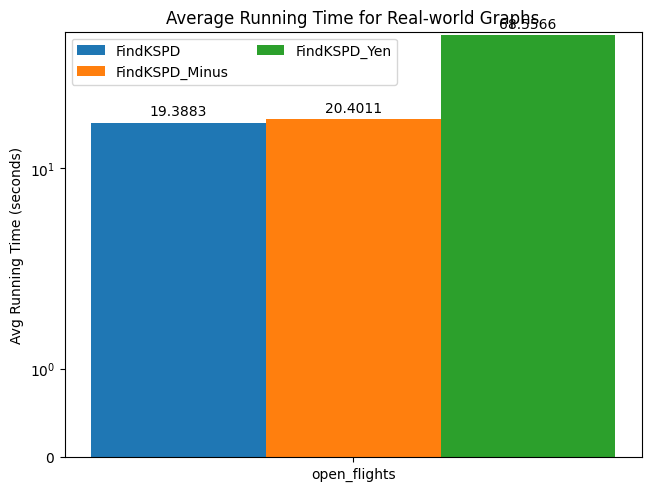

/content/k_shortest_path_with_diversity/examples/draw_bar_chart.py:38: UserWarning: The figure layout has changed to tight
  fig.tight_layout() # Added for better layout


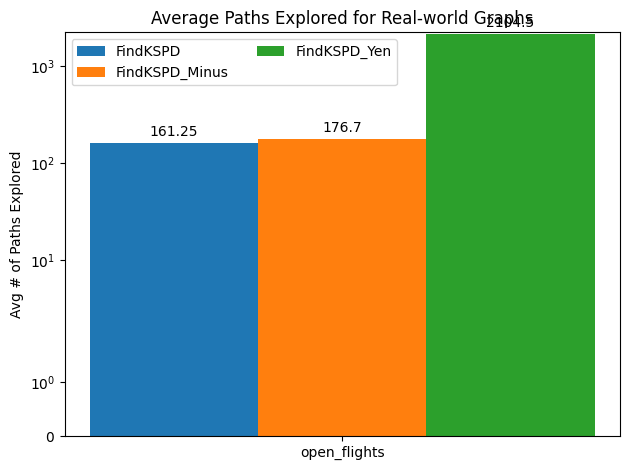

In [14]:
all_results = [open_flights_result]

graph_types = ("open_flights", )

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

In [18]:
soc_Slashdot_path = "/content/graph-data/soc-Slashdot0811.txt"
num_pairs = 20
G, node_pairs = upload_graph(soc_Slashdot_path, num_pairs)
print(node_pairs)

[(65649, 74834), (11519, 52411), (64745, 31595), (49105, 75393), (70118, 75806), (1051, 54596), (53411, 40279), (5178, 1549), (22845, 77053), (21684, 28481), (6286, 3829), (49539, 62534), (65994, 39297), (35682, 57307), (15540, 9040), (33675, 31991), (68582, 9117), (33572, 50351), (42220, 60611), (32821, 42794)]


In [19]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

working with KSPD

Comparing algorithms for SRC: 65649, DEST: 74834

Comparing algorithms for SRC: 11519, DEST: 52411

Comparing algorithms for SRC: 64745, DEST: 31595

Comparing algorithms for SRC: 49105, DEST: 75393

Comparing algorithms for SRC: 70118, DEST: 75806

Comparing algorithms for SRC: 1051, DEST: 54596

Comparing algorithms for SRC: 53411, DEST: 40279

Comparing algorithms for SRC: 5178, DEST: 1549

Comparing algorithms for SRC: 22845, DEST: 77053

Comparing algorithms for SRC: 21684, DEST: 28481

Comparing algorithms for SRC: 6286, DEST: 3829

Comparing algorithms for SRC: 49539, DEST: 62534

Comparing algorithms for SRC: 65994, DEST: 39297

Comparing algorithms for SRC: 35682, DEST: 57307

Comparing algorithms for SRC: 15540, DEST: 9040

Comparing algorithms for SRC: 33675, DEST: 31991

Comparing algorithms for SRC: 68582, DEST: 9117

Comparing algorithms for SRC: 33572, DEST: 50351

Comparing algorithms for SRC: 42220, DEST: 60611

Comparing algorithms for SRC: 32821, D

In [20]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

working with KSPD_Minus

Comparing algorithms for SRC: 65649, DEST: 74834

Comparing algorithms for SRC: 11519, DEST: 52411

Comparing algorithms for SRC: 64745, DEST: 31595

Comparing algorithms for SRC: 49105, DEST: 75393

Comparing algorithms for SRC: 70118, DEST: 75806

Comparing algorithms for SRC: 1051, DEST: 54596

Comparing algorithms for SRC: 53411, DEST: 40279

Comparing algorithms for SRC: 5178, DEST: 1549

Comparing algorithms for SRC: 22845, DEST: 77053

Comparing algorithms for SRC: 21684, DEST: 28481

Comparing algorithms for SRC: 6286, DEST: 3829

Comparing algorithms for SRC: 49539, DEST: 62534

Comparing algorithms for SRC: 65994, DEST: 39297

Comparing algorithms for SRC: 35682, DEST: 57307

Comparing algorithms for SRC: 15540, DEST: 9040

Comparing algorithms for SRC: 33675, DEST: 31991

Comparing algorithms for SRC: 68582, DEST: 9117

Comparing algorithms for SRC: 33572, DEST: 50351

Comparing algorithms for SRC: 42220, DEST: 60611

Comparing algorithms for SRC: 32

In [21]:
print("working with KSPD_Yen")
kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

print(f"kspd_yen_times: {kspd_yen_times}")
print(f"kspd_yen_num_paths: {kspd_yen_num_paths}")
print(f"kspd_yen_avg_time: {kspd_yen_avg_time}")
print(f"kspd_yen_avg_num_paths: {kspd_yen_avg_num_paths}")

working with KSPD_Yen

Comparing algorithms for SRC: 65649, DEST: 74834

Comparing algorithms for SRC: 11519, DEST: 52411

Comparing algorithms for SRC: 64745, DEST: 31595

Comparing algorithms for SRC: 49105, DEST: 75393

Comparing algorithms for SRC: 70118, DEST: 75806

Comparing algorithms for SRC: 1051, DEST: 54596

Comparing algorithms for SRC: 53411, DEST: 40279

Comparing algorithms for SRC: 5178, DEST: 1549

Comparing algorithms for SRC: 22845, DEST: 77053

Comparing algorithms for SRC: 21684, DEST: 28481

Comparing algorithms for SRC: 6286, DEST: 3829

Comparing algorithms for SRC: 49539, DEST: 62534

Comparing algorithms for SRC: 65994, DEST: 39297

Comparing algorithms for SRC: 35682, DEST: 57307

Comparing algorithms for SRC: 15540, DEST: 9040

Comparing algorithms for SRC: 33675, DEST: 31991

Comparing algorithms for SRC: 68582, DEST: 9117

Comparing algorithms for SRC: 33572, DEST: 50351

Comparing algorithms for SRC: 42220, DEST: 60611

Comparing algorithms for SRC: 3282

In [22]:
soc_Slashdot_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(soc_Slashdot_result)

((np.float64(10.0252473), np.float64(9.0), [12.733351, 12.043793, 6.834943, 11.722015, 10.95881, 9.801857, 10.049555, 4.595234, 12.155952, 10.143584, 6.704356, 11.718281, 10.386511, 11.662771, 6.968781, 11.200068, 9.340402, 10.135495, 11.168448, 10.180739], [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]), (np.float64(10.139101), np.float64(9.0), [10.762628, 11.849775, 7.129801, 10.708177, 10.324803, 10.769751, 11.844784, 4.679143, 10.824583, 11.577302, 6.934876, 10.780264, 10.700297, 11.847995, 8.100721, 10.741516, 10.943843, 10.538934, 10.59259, 11.130237], [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]), (np.float64(36.399213450000005), np.float64(40.85), [53.389871, 35.52769, 31.971785, 52.902954, 52.742143, 34.608522, 35.557477, 4.325695, 100.320346, 30.289741, 8.557077, 35.491971, 41.396663, 38.190061, 14.091509, 33.688937, 24.118584, 27.793842, 35.451085, 37.568316], [39, 41, 37, 40, 40, 39, 40, 29, 108, 40, 28, 44, 50, 41, 32, 29, 40, 30, 26, 44]))


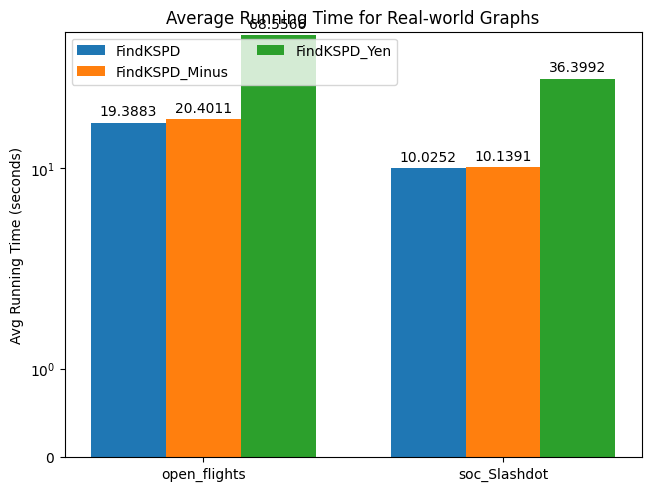

/content/k_shortest_path_with_diversity/examples/draw_bar_chart.py:38: UserWarning: The figure layout has changed to tight
  fig.tight_layout() # Added for better layout


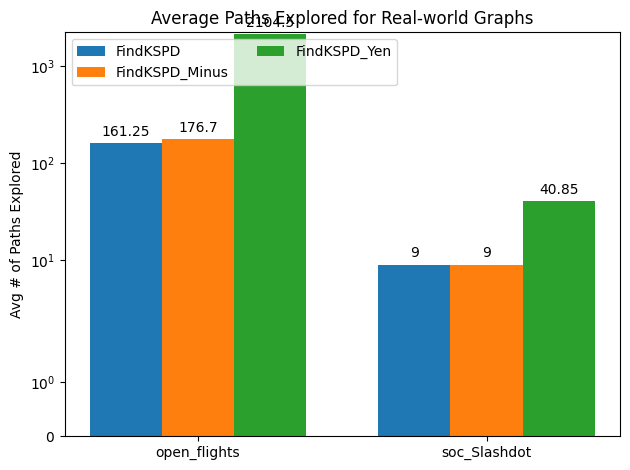

In [23]:
all_results.append(soc_Slashdot_result)

graph_types = ("open_flights", "soc_Slashdot")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [26]:
web_google_path = "/content/graph-data/web-Google.txt"
num_pairs = 20
G, node_pairs = upload_graph(web_google_path, num_pairs)

print(node_pairs)

[(845433, 249999), (797909, 730307), (552125, 187027), (728600, 108850), (598176, 642096), (590406, 192924), (253924, 196810), (849905, 254791), (28190, 523723), (163722, 764668), (850184, 213837), (362184, 485908), (751927, 473717), (682834, 36658), (836886, 260802), (792980, 183946), (599948, 911314), (794322, 875409), (503451, 777055), (778413, 204873)]


In [27]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

working with KSPD

Comparing algorithms for SRC: 845433, DEST: 249999

Comparing algorithms for SRC: 797909, DEST: 730307

Comparing algorithms for SRC: 552125, DEST: 187027

Comparing algorithms for SRC: 728600, DEST: 108850

Comparing algorithms for SRC: 598176, DEST: 642096

Comparing algorithms for SRC: 590406, DEST: 192924

Comparing algorithms for SRC: 253924, DEST: 196810

Comparing algorithms for SRC: 849905, DEST: 254791

Comparing algorithms for SRC: 28190, DEST: 523723

Comparing algorithms for SRC: 163722, DEST: 764668

Comparing algorithms for SRC: 850184, DEST: 213837

Comparing algorithms for SRC: 362184, DEST: 485908

Comparing algorithms for SRC: 751927, DEST: 473717

Comparing algorithms for SRC: 682834, DEST: 36658

Comparing algorithms for SRC: 836886, DEST: 260802

Comparing algorithms for SRC: 792980, DEST: 183946

Comparing algorithms for SRC: 599948, DEST: 911314

Comparing algorithms for SRC: 794322, DEST: 875409

Comparing algorithms for SRC: 503451, DEST: 777

In [28]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

working with KSPD_Minus

Comparing algorithms for SRC: 845433, DEST: 249999

Comparing algorithms for SRC: 797909, DEST: 730307

Comparing algorithms for SRC: 552125, DEST: 187027

Comparing algorithms for SRC: 728600, DEST: 108850

Comparing algorithms for SRC: 598176, DEST: 642096

Comparing algorithms for SRC: 590406, DEST: 192924

Comparing algorithms for SRC: 253924, DEST: 196810

Comparing algorithms for SRC: 849905, DEST: 254791

Comparing algorithms for SRC: 28190, DEST: 523723

Comparing algorithms for SRC: 163722, DEST: 764668

Comparing algorithms for SRC: 850184, DEST: 213837

Comparing algorithms for SRC: 362184, DEST: 485908

Comparing algorithms for SRC: 751927, DEST: 473717

Comparing algorithms for SRC: 682834, DEST: 36658

Comparing algorithms for SRC: 836886, DEST: 260802

Comparing algorithms for SRC: 792980, DEST: 183946

Comparing algorithms for SRC: 599948, DEST: 911314

Comparing algorithms for SRC: 794322, DEST: 875409

Comparing algorithms for SRC: 503451, DES

In [29]:
print("working with KSPD_Yen")
kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

print(f"kspd_yen_times: {kspd_yen_times}")
print(f"kspd_yen_num_paths: {kspd_yen_num_paths}")
print(f"kspd_yen_avg_time: {kspd_yen_avg_time}")
print(f"kspd_yen_avg_num_paths: {kspd_yen_avg_num_paths}")

# kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
# kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

# kspd_yen_avg_time = 10**6
# kspd_yen_avg_num_paths =  10**6

working with KSPD_Yen

Comparing algorithms for SRC: 845433, DEST: 249999

Comparing algorithms for SRC: 797909, DEST: 730307

Comparing algorithms for SRC: 552125, DEST: 187027


KeyboardInterrupt: 

In [ ]:
web_google_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(web_google_result)

In [ ]:
graph_types = ("web-Google",)

algorithms_time = {
    'FindKSPD':       [web_google_result[0][0]],  # index 0 = avg_time
    'FindKSPD_Minus': [web_google_result[1][0]],
    'FindKSPD_Yen':   [web_google_result[2][0]],
}

algorithms_paths = {
    'FindKSPD':       [web_google_result[0][1]],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [web_google_result[1][1]],
    'FindKSPD_Yen':   [web_google_result[2][1]],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

In [ ]:
wiki_talk_path  = "/content/graph-data/wiki-Talk.txt"
num_pairs = 50
G, node_pairs = upload_graph(wiki_talk_path, num_pairs)
print(node_pairs)

In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
wiki_talk_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(wiki_talk_result)

In [ ]:
all_results = [web_google_result, wiki_talk_result]

graph_types = ("web-Google", "wiki-Talk")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

In [ ]:
all_kspd_times = []
all_kspd_minus_times = []
all_kspd_yen_times = []

all_kspd_num_paths = []
all_kspd_minus_num_paths = []
all_kspd_yen_num_paths = []

for graph_result in all_results:
    all_kspd_times.extend(graph_result[0][2])
    all_kspd_num_paths.extend(graph_result[0][3])

    all_kspd_minus_times.extend(graph_result[1][2])
    all_kspd_minus_num_paths.extend(graph_result[1][3])

    all_kspd_yen_times.extend(graph_result[2][2])
    all_kspd_yen_num_paths.extend(graph_result[2][3])

# Plotting distributions for times
plot_configs_time = [
    ('FindKSPD Execution Times', all_kspd_times, 'skyblue'),
    ('FindKSPD_Minus Execution Times', all_kspd_minus_times, 'lightcoral'),
    ('FindKSPD_Yen Execution Times', all_kspd_yen_times, 'lightgreen'),
]
draw_time_distribution(plot_configs_time)

# Plotting distributions for number of paths
plot_configs_num_paths = [
    ('FindKSPD Number of Paths Explored', all_kspd_num_paths, 'skyblue'),
    ('FindKSPD_Minus Number of Paths Explored', all_kspd_minus_num_paths, 'lightcoral'),
    ('FindKSPD_Yen Number of Paths Explored', all_kspd_yen_num_paths, 'lightgreen'),
]
draw_num_of_path_distribution(plot_configs_num_paths)